# SPCA Classification - zoo data

This notebook performs supervised PCA with classification on a zoological dataset with 100+ animals. Each animal is annotated with 16 attributes (has hair, has feathers, flies etc.) and belongs to one of 7 classes (mammal, fish, etc.).

The SPCA Classification model jointly learns a 2D latent projection and a linear classifier, balancing reconstruction and classification objectives via the regularization parameter $\lambda$.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, scale_features

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [3]:
# Load zoo data
E_raw, C, names, feature_names, class_names = load_zoo_data(device)

# Scale and center features
E = scale_features(E_raw)
E = E - E.mean(dim=0)

## Model training

We train the SPCA Classification model with $\lambda = 0.01$, which puts more weight on the supervised classification error while retaining some unsupervised reconstruction signal.

In [4]:
# Initialize SPCA classification model
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)

# Train model
lam = 0.01  # regularization parameter lambda
steps = 1000
model.train(E, C, lam=lam, steps=steps, classifier_epochs=50)

Step 0: loss = 3.1533, classifier loss = 1.8550
Step 10: loss = 2.4905, classifier loss = 1.1878
Step 20: loss = 2.2222, classifier loss = 0.9170
Step 30: loss = 2.0962, classifier loss = 0.7900
Step 40: loss = 2.0202, classifier loss = 0.7130
Step 50: loss = 1.9656, classifier loss = 0.6578
Step 60: loss = 1.9224, classifier loss = 0.6138
Step 70: loss = 1.8864, classifier loss = 0.5772
Step 80: loss = 1.8553, classifier loss = 0.5456
Step 90: loss = 1.8281, classifier loss = 0.5180
Step 100: loss = 1.8039, classifier loss = 0.4934
Step 110: loss = 1.7818, classifier loss = 0.4708
Step 120: loss = 1.7613, classifier loss = 0.4491
Step 130: loss = 1.7417, classifier loss = 0.4274
Step 140: loss = 1.7233, classifier loss = 0.4063
Step 150: loss = 1.7060, classifier loss = 0.3851
Step 160: loss = 1.6899, classifier loss = 0.3647
Step 170: loss = 1.6751, classifier loss = 0.3457
Step 180: loss = 1.6616, classifier loss = 0.3282
Step 190: loss = 1.6493, classifier loss = 0.3123
Step 200: l

## Normalization

Two steps are applied:
1. **Loadings normalization** -- center `L` at zero and scale so the longest loading vector has norm 1 (matching FreeVIZ's `normalize()` step).
2. **Projection normalization** -- scale the projected points `Z` so the maximum absolute coordinate equals 1, confining all data points to `[-1, 1]`.

This makes the resulting vizualization analogous to the Freeviz one, which helps with side-by-side comparison

In [5]:
# Extract latent projections
L = model.L.detach().clone()

# 1. Normalize loadings: center and scale to max norm = 1
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

# 2. Project and scale data points to [-1, 1]
Z = E @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np = C.cpu().numpy()
L_np = L.cpu().numpy()

## Vizualization

We project the data onto the learned SPCA axes and overlay the feature loading vectors, which results in a final result analogous to Freeviz.

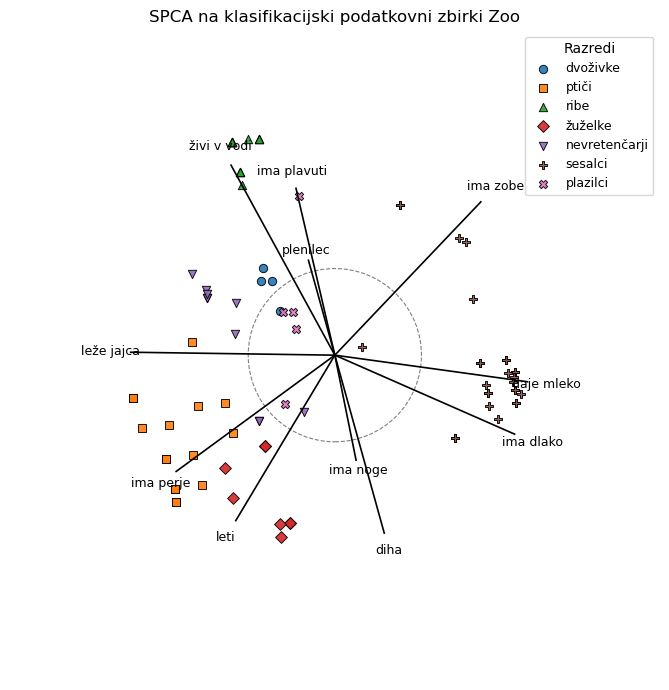

In [6]:
unique_classes = np.unique(C_np)
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
cmap = plt.get_cmap('tab10')
plt.figure(figsize=(7, 7))

# Plot points by class
for i, cls in enumerate(unique_classes):
    idx = C_np == cls
    plt.scatter(
        Z_np[idx, 0],
        Z_np[idx, 1],
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        label=class_names[int(cls)],
        edgecolors='black',
        linewidths=0.7,
        alpha=0.9
    )

# set and vizualize the minimal length of the feature vecrors to appear
loading_cutoff = 0.4
circle = plt.Circle((0, 0), loading_cutoff, fill=False, linestyle='--', linewidth=0.8, color='gray')
plt.gca().add_patch(circle)

# Plot projection vectors (loadings of features) with labels
for i, vec in enumerate(L_np):
    x, y = vec
    length = np.sqrt(x**2 + y**2)
    if length > loading_cutoff:
        plt.plot([0, x], [0, y], linestyle='-', linewidth=1.2, color='black')
        plt.text(
            x * 1.1, y * 1.1,
            feature_names[i],
            fontsize=9,
            ha='center',
            va='center'
        )

# Configure axes
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal', 'box')
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.legend(title='Razredi', loc='upper right', frameon=True, fontsize=9, title_fontsize=10)

plt.title('SPCA na klasifikacijski podatkovni zbirki Zoo')
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_classification_zoo_projection.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_classification_zoo_projection.png", format="png", bbox_inches="tight")
plt.show()

## Lambda Sweep: Effect of Regularization on Target Metrics

We sweep $\lambda$ (the trade-off between classification and reconstruction) and track:
- **Variation explained**: Fraction of $\|X\|_F^2$ captured by the low-rank reconstruction $XLL^\top$
- **Classification accuracy**: On a held-out test set (20% split)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Step 0: loss = 1.8581, classifier loss = 1.8502
Step 10: loss = 1.1968, classifier loss = 1.1874
Step 20: loss = 0.9305, classifier loss = 0.9200
Step 30: loss = 0.7941, classifier loss = 0.7834
Step 40: loss = 0.6801, classifier loss = 0.6687
Step 50: loss = 0.5855, classifier loss = 0.5733
Step 60: loss = 0.5121, classifier loss = 0.4995
Step 70: loss = 0.4527, classifier loss = 0.4399
Step 80: loss = 0.4030, classifier loss = 0.3900
Step 90: loss = 0.3607, classifier loss = 0.3475
Step 100: loss = 0.3245, classifier loss = 0.3111
Step 110: loss = 0.2934, classifier loss = 0.2798
Step 120: loss = 0.2665, classifier loss = 0.2528
Step 130: loss = 0.2432, classifier loss = 0.2293
Step 140: loss = 0.2230, classifier loss = 0.2090
Step 150: loss = 0.2054, classifier loss = 0.1912
Step 160: loss = 0.1899, classifier loss = 0.1756
Step 170: loss = 0.1762, classifier loss = 0.1618
Step 180: loss = 0.1639, classifier loss = 0.1495
Step 190: loss = 0.1527, classifier loss = 0.1382
Step 200: l

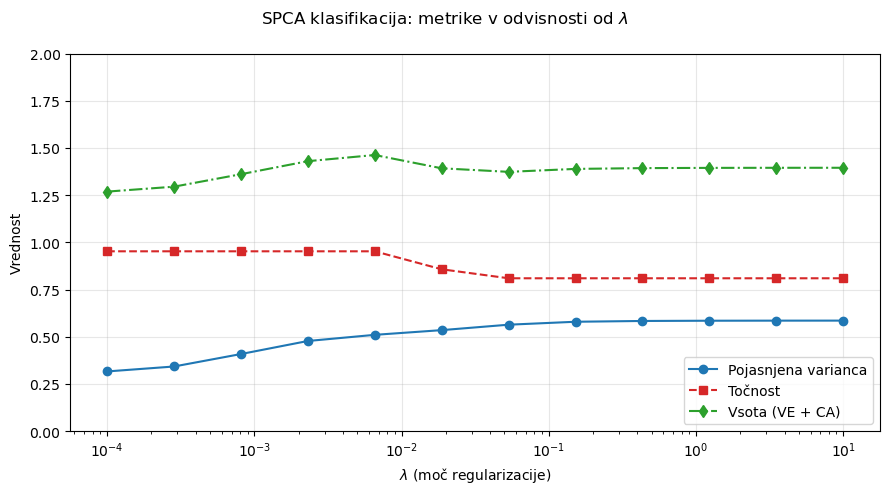

In [7]:
from sklearn.model_selection import train_test_split
from utils import variation_explained

# Train/test split
E_np = E.cpu().numpy()
C_np = C.cpu().numpy()
E_train, E_test, C_train, C_test = train_test_split(
    E_np, C_np, test_size=0.2, random_state=42
)

E_train = torch.tensor(E_train, dtype=torch.float64, device=device)
E_test  = torch.tensor(E_test,  dtype=torch.float64, device=device)
C_train = torch.tensor(C_train, dtype=torch.long, device=device)
C_test  = torch.tensor(C_test,  dtype=torch.long, device=device)

# Center both sets by training mean
train_mean = E_train.mean(dim=0, keepdim=True)
E_train -= train_mean
E_test  -= train_mean

# Lambda values on log scale
lam_values = np.logspace(-4, 1, 12)
var_explained = []
accuracies = []
models_by_lam = {}  # save models for later viz

for lam in lam_values:
    model = SPCA_Classification(
        input_dim=E_train.shape[1], latent_dim=2,
        num_classes=len(class_names), lr=0.05
    ).to(device)
    model.train(E_train, C_train, lam=lam, steps=500, classifier_epochs=50)

    L = model.L.detach()

    # Variation explained on test set
    ve = variation_explained(E_test, L)
    var_explained.append(ve.item())

    # Classification accuracy on test set
    logits = model.classify_logits(E_test)
    preds = torch.argmax(logits, dim=1)
    acc = (preds == C_test).float().mean()
    accuracies.append(acc.item())

    print(f"$\\lambda$ = {lam:.6f}:  var_exp = {ve.item():.4f},  accuracy = {acc.item():.4f}")

    # Save model for later visualization
    models_by_lam[lam] = model

sum_metric = [v + a for v, a in zip(var_explained, accuracies)]

# Single plot with shared y-axis
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(lam_values, var_explained, 'o-', color='tab:blue', label='Pojasnjena varianca')
ax.semilogx(lam_values, accuracies, 's--', color='tab:red', label='Točnost')
ax.semilogx(lam_values, sum_metric, 'd-.', color='tab:green', label='Vsota (VE + CA)')

ax.set_xlabel('$\\lambda$ (moč regularizacije)')
ax.set_ylabel('Vrednost')
ax.set_ylim(0, 2)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')

fig.suptitle('SPCA klasifikacija: metrike v odvisnosti od $\\lambda$')
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_classification_zoo_lambda_metrics.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_classification_zoo_lambda_metrics.png", format="png", bbox_inches="tight")
plt.show()

## 2D Projections for Selected $\lambda$ Values

We visualize the latent projections and feature loadings for four $\lambda$ values. The closest to the max VE + CA sum ($\lambda$ achieving best combined reconstruction-classification trade-off) replaces the nearest pre-selected $\lambda$:
- $\lambda = 10^{-4}$ (almost pure classification, weak reconstruction)
- $\lambda \approx 2.3 \times 10^{-3}$ (balanced)
- $\lambda$ achieving max sum (best combined trade-off)
- $\lambda = 10$ (dominated by reconstruction, near PCA)

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


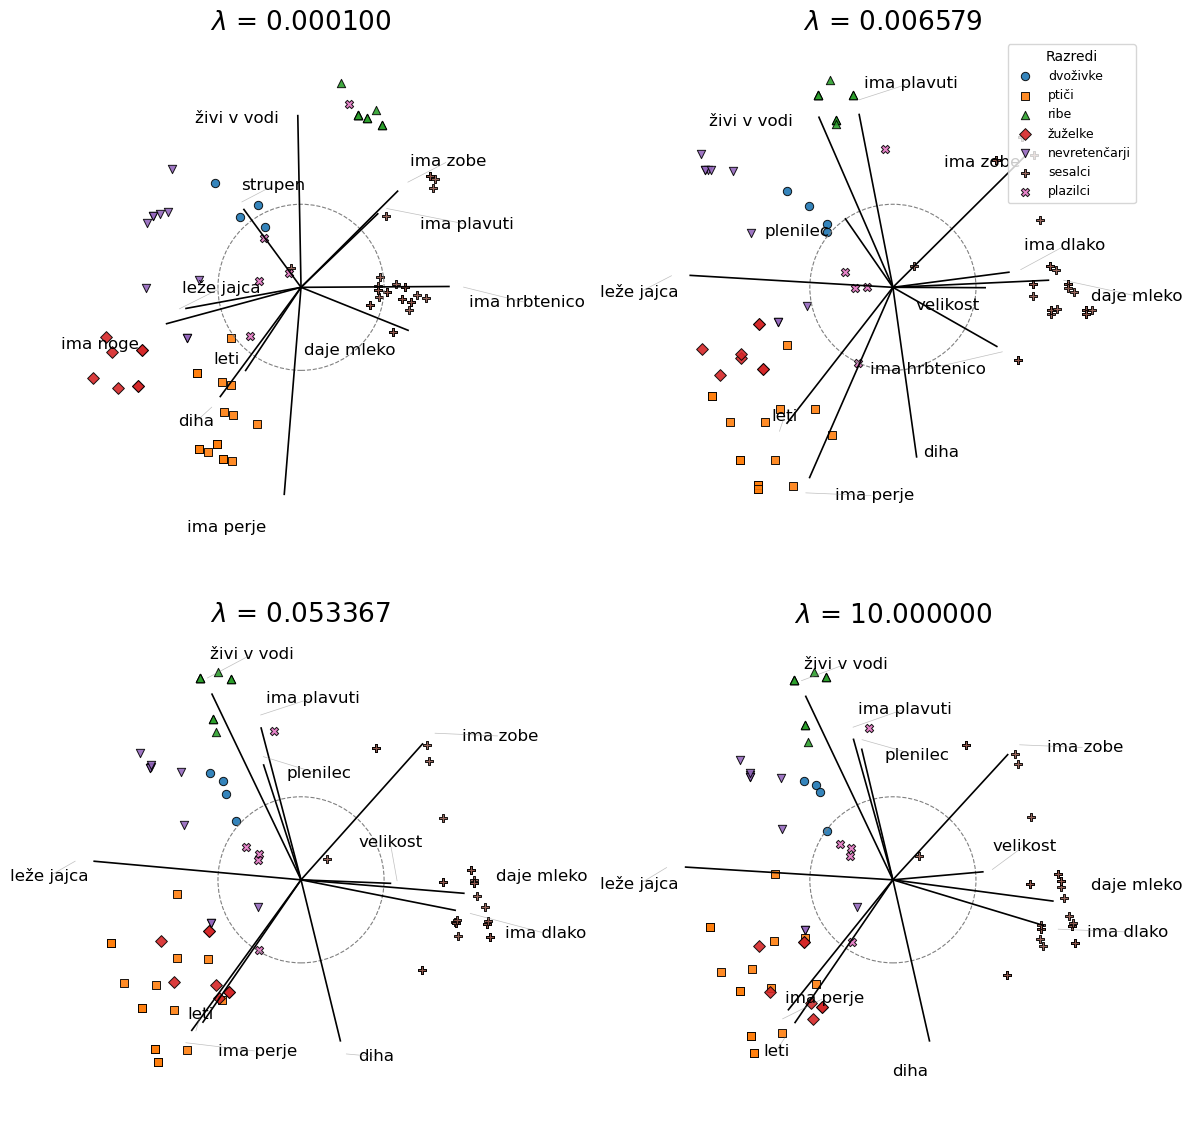

In [8]:
from utils import plot_projection

max_sum = max(sum_metric)
max_idx = sum_metric.index(max_sum)
max_lam = lam_values[max_idx]

viz_lam_values = [lam_values[0], lam_values[3], lam_values[6], lam_values[-1]]
closest_idx = min(range(len(viz_lam_values)), key=lambda i: abs(viz_lam_values[i] - max_lam))
viz_lam_values[closest_idx] = max_lam
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

E_full = E.to(torch.float64)
C_full = C

for idx, lam in enumerate(viz_lam_values):
    model = models_by_lam[lam]
    L = model.L.detach().clone()

    # Normalize loadings: center and scale to max norm = 1
    L = L - L.mean(dim=0, keepdim=True)
    loading_norms = torch.norm(L, dim=1)
    L = L / loading_norms.max()

    # Project and scale points using full data
    Z = E_full @ L
    z_max = torch.abs(Z).max()
    Z = Z / z_max

    Z_np = Z.cpu().numpy()
    C_np = C_full.cpu().numpy()
    L_np = L.cpu().numpy()

    plot_projection(
        points=Z_np, vectors=L_np, feature_names=feature_names,
        class_codes=C_np, class_names=class_names,
        title=f'$\\lambda$ = {lam:.6f}', ax=axes.flat[idx], text_scale=1.08,
        max_points=None, title_fontsize=19, label_fontsize=12
    )

for i, ax in enumerate(axes.flat):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if i != 1:
        ax.legend_.remove()
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.savefig("../final_vizualizations/spca_classification_zoo_lambda_projections.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_classification_zoo_lambda_projections.png", format="png", bbox_inches="tight")
plt.show()